<a href="https://colab.research.google.com/github/bansal1600/EfficientML.ai-Inference-Optimization/blob/main/linear_quantization_tensor_channel_grouped.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. The Math of Linear Quantization
Linear (or Affine) quantization maps a range of floating-point values $[f_{min}, f_{max}]$ to a range of integers $[q_{min}, q_{max}]$.

**The Formula:**
$$q = \text{clamp}(\lfloor \frac{f}{S} \rceil + Z, q_{min}, q_{max})$$
$$f \approx S \times (q - Z)$$

- **Scale ($S$):** $(f_{max} - f_{min}) / (q_{max} - q_{min})$
- **Zero-Point ($Z$):** $q_{min} - f_{min}/S$ (then rounded and clamped)


### 2. Symmetric vs Asymmetric
In the code above, we use **Asymmetric Quantization** because we calculate a `zero_point`.
- If we forced the range to be centered at zero (e.g., -10 to 10), the $Z$ would be 0, which is called **Symmetric Quantization**.


### 3. Why Per-Channel?
Imagine a weight matrix where one row has values between [0, 1] and another has values between [-100, 100].
- **Per-Tensor:** One scale must cover [-100, 100]. The row with [0, 1] will lose almost all its detail (becoming mostly zeros).
- **Per-Channel:** Each row gets its own scale. The [0, 1] row gets a tiny scale, preserving its precision.

In [7]:
import torch

def linear_quantize(tensor, scale, zero_point, dtype=torch.int8):
    """Standard affine quantization: q = round(f / scale + zero_point)"""
    q = (tensor / scale) + zero_point
    q = torch.round(q)
    # Clamp to the range of the target data type
    q = torch.clamp(q, -128, 127)
    return q.to(dtype)

def dequantize(q_tensor, scale, zero_point):
    """Standard dequantization: f = scale * (q - zero_point)"""
    return scale * (q_tensor.float() - zero_point)

# Example weights
weights = torch.randn(2, 3) * 10
print("Original Weights:\n", weights)

Original Weights:
 tensor([[-13.6312,  -6.1270,  -7.1592],
        [  3.7736,  -8.7787,  21.1748]])


In [8]:
def get_quantization_params(tensor, num_bits=8):
    """Calculates scale and zero point for asymmetric quantization"""
    qmin = - (2**(num_bits - 1))
    qmax = (2**(num_bits - 1)) - 1

    fmin = tensor.min().item()
    fmax = tensor.max().item()

    scale = (fmax - fmin) / (qmax - qmin)
    # zero_point = round(qmin - fmin / scale)
    initial_zero_point = qmin - fmin / scale
    zero_point = max(qmin, min(qmax, round(initial_zero_point)))

    return scale, zero_point

scale, zp = get_quantization_params(weights)
quantized = linear_quantize(weights, scale, zp)
dequantized = dequantize(quantized, scale, zp)

print(f"Scale: {scale}, Zero Point: {zp}")
print("Quantized (INT8):\n", quantized)
print("Dequantized (FP32 Error):\n", weights - dequantized)

Scale: 0.13649413164924173, Zero Point: -28
Quantized (INT8):
 tensor([[-128,  -73,  -80],
        [   0,  -92,  127]], dtype=torch.int8)
Dequantized (FP32 Error):
 tensor([[ 0.0182,  0.0152, -0.0615],
        [-0.0483, -0.0430,  0.0182]])


In [12]:
from transformers import AutoModel
import torch

# Load a small foundation model (GPT-2)
model = AutoModel.from_pretrained('gpt2')

# Get the weights of the first layer's attention projection
foundation_weights = model.h[0].attn.c_attn.weight.data
print(f"Foundation Layer Shape: {foundation_weights.shape}")

# Let's calculate the quantization error for Per-Tensor vs Per-Channel
# 1. Per-Tensor
s_t, zp_t = get_quantization_params(foundation_weights)
q_t = linear_quantize(foundation_weights, s_t, zp_t)
dq_t = dequantize(q_t, s_t, zp_t)
error_t = torch.abs(foundation_weights - dq_t).mean().item()

# 2. Per-Channel (Rows)
errors_c = []
for i in range(foundation_weights.shape[0]):
    s_c, zp_c = get_quantization_params(foundation_weights[i])
    q_c = linear_quantize(foundation_weights[i], s_c, zp_c)
    dq_c = dequantize(q_c, s_c, zp_c)
    errors_c.append(torch.abs(foundation_weights[i] - dq_c).mean().item())

print(f"Average Per-Tensor Error: {error_t:.6f}")
print(f"Average Per-Channel Error: {sum(errors_c)/len(errors_c):.6f}")

avg_error_c = sum(errors_c) / len(errors_c)
print(f"Average Per-Tensor Error: {error_t:.6f}")
print(f"Average Per-Channel Error: {avg_error_c:.6f}")
print(f"Improvement: {((error_t - avg_error_c) / error_t) * 100:.2f}%")

print("Per-channel quantization allows for more precision if different rows have different distributions.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Foundation Layer Shape: torch.Size([768, 2304])
Average Per-Tensor Error: 0.005527
Average Per-Channel Error: 0.001998
Average Per-Tensor Error: 0.005527
Average Per-Channel Error: 0.001998
Improvement: 63.85%
Per-channel quantization allows for more precision if different rows have different distributions.


In [14]:
import os

# Calculate theoretical memory usage
# 1. Original weights (FP32 = 4 bytes per element)
fp32_mem = foundation_weights.nelement() * 4 / (1024**2)

# 2. Quantized weights (INT8 = 1 byte per element)
# Plus the scales and zero points for per-channel quantization
int8_mem_weights = foundation_weights.nelement() * 1 / (1024**2)

# Per-channel scales (FP32) and ZPs (INT8) - one per row (768)
overhead_mem = (foundation_weights.shape[0] * 4 + foundation_weights.shape[0] * 1) / (1024**2)
total_int8_mem = int8_mem_weights + overhead_mem

print(f"Original (FP32) Memory: {fp32_mem:.2f} MB")
print(f"Quantized (INT8) Memory: {total_int8_mem:.2f} MB")
print(f"Memory Reduction: {(1 - total_int8_mem/fp32_mem)*100:.2f}%")

# 3. Check physical file size if saved
if os.path.exists('quantized_model_layer.pt'):
    file_size = os.path.getsize('quantized_model_layer.pt') / (1024**2)
    print(f"Actual saved file size: {file_size:.2f} MB")

Original (FP32) Memory: 6.75 MB
Quantized (INT8) Memory: 1.69 MB
Memory Reduction: 74.95%
Actual saved file size: 1.69 MB


### 1. GPT Layer Sensitivity
In a standard GPT (Transformer) model, here is the 'Quantization Map':

| Layer Type | Role | Quantize? | Reason |
| :--- | :--- | :--- | :--- |
| **Embedding** | Maps words to vectors | **No/High Precision** | First layer; small errors here magnify as they go deeper. |
| **Attention (Q, K, V)** | Finds relationships between words | **Yes (INT8/4)** | These are the largest matrices; huge memory savings here. |
| **Feed-Forward (FFN)** | Processes the word meanings | **Yes (INT8/4)** | Takes up ~60% of model parameters. High impact on size. |
| **LayerNorm** | Keeps numbers in a stable range | **No (FP32)** | Very few parameters; keeps the math stable. |
| **LM Head** | Predicts the next word | **No (FP16/32)** | The final decision layer. Errors here lead to gibberish output. |

### 2. How to measure accuracy without a dataset?
When we don't have a specific task (like 'classify cats'), we use **Perplexity**.

**Perplexity** measures how 'surprised' the model is by a sequence of text.
- **Low Perplexity:** The model predicts the next words confidently (Good).
- **High Perplexity:** The model is confused (Bad quantization).

We simply feed the model a chunk of Wikipedia or a book and see if the quantized version is more 'surprised' than the original.

In [15]:
import torch

def calculate_mock_perplexity(original_logits, quantized_logits):
    """
    A simplified way to see how much the 'opinion' of the model changed.
    We use KL Divergence to measure the 'distance' between the distributions.
    """
    # Turn raw outputs into probabilities
    prob_orig = torch.nn.functional.softmax(original_logits, dim=-1)
    prob_quant = torch.nn.functional.softmax(quantized_logits, dim=-1)

    # Measure the 'distance' (Lower is better)
    loss = torch.nn.functional.kl_div(prob_quant.log(), prob_orig, reduction='batchmean')
    return loss.item()

# Imagine these are the 'predictions' for the next word from both models
orig_output = torch.randn(1, 50257) # GPT-2 vocab size
quant_output = orig_output + (torch.randn(1, 50257) * 0.1) # Add some quantization noise

error_score = calculate_mock_perplexity(orig_output, quant_output)
print(f"Quantization Divergence (Lower is better): {error_score:.6f}")

Quantization Divergence (Lower is better): 0.005013


### 4. Per-Group Quantization
If a row is very long (e.g., 4096 elements), some parts of the row might have different ranges than others.
- **Concept**: Split the row into groups of size `G`.
- **Math**: $q = \text{round}(f / S_{group} + Z_{group})$

In [23]:
def quantize_per_group(tensor, group_size=64):
    # 1. Reshape the tensor to isolate the groups
    # original: [rows, cols] -> [rows, num_groups, group_size]
    rows, cols = tensor.shape
    num_groups = cols // group_size
    reshaped = tensor.view(rows, num_groups, group_size)

    # 2. Calculate scale/zp for each group
    # We treat each group as its own 'mini-tensor'
    fmin = reshaped.min(dim=-1, keepdim=True).values
    fmax = reshaped.max(dim=-1, keepdim=True).values

    qmin, qmax = -128, 127
    scales = (fmax - fmin) / (qmax - qmin)
    # Avoid division by zero
    scales = torch.clamp(scales, min=1e-8)

    # 3. Quantize
    q = torch.round(reshaped / scales)
    q = torch.clamp(q, qmin, qmax).to(torch.int8)

    return q, scales

# Try it on our foundation weights
group_size = 128
q_groups, s_groups = quantize_per_group(foundation_weights, group_size=group_size)

print(f"Original Shape: {foundation_weights.shape}")
print(f"Quantized Grouped Shape: {q_groups.shape}")
print(f"Number of Scales: {s_groups.nelement()} (vs 768 for per-channel)")

Original Shape: torch.Size([768, 2304])
Quantized Grouped Shape: torch.Size([768, 18, 128])
Number of Scales: 13824 (vs 768 for per-channel)


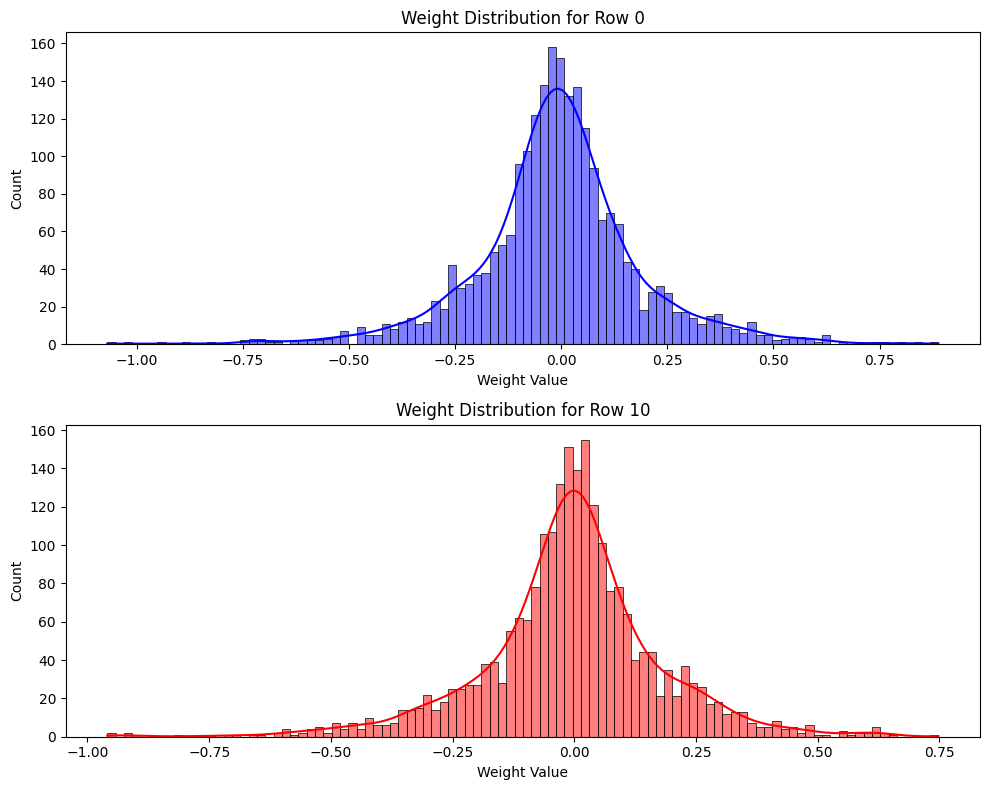

Row 0 Range: [-1.0691, 0.8887]
Row 10 Range: [-0.9592, 0.7479]


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's pick two different rows from the foundation weights
row_idx_1 = 0
row_idx_2 = 10  # Pick a different one to see the variation

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot distribution for Row 1
sns.histplot(foundation_weights[row_idx_1].numpy(), bins=100, ax=axes[0], color='blue', kde=True)
axes[0].set_title(f"Weight Distribution for Row {row_idx_1}")
axes[0].set_xlabel("Weight Value")

# Plot distribution for Row 2
sns.histplot(foundation_weights[row_idx_2].numpy(), bins=100, ax=axes[1], color='red', kde=True)
axes[1].set_title(f"Weight Distribution for Row {row_idx_2}")
axes[1].set_xlabel("Weight Value")

plt.tight_layout()
plt.show()

# Print the ranges to see the 'outlier' effect
print(f"Row {row_idx_1} Range: [{foundation_weights[row_idx_1].min():.4f}, {foundation_weights[row_idx_1].max():.4f}]")
print(f"Row {row_idx_2} Range: [{foundation_weights[row_idx_2].min():.4f}, {foundation_weights[row_idx_2].max():.4f}]")

### Visualizing the 'Outlier' Problem
If Row 0 has a range of [-0.1, 0.1] and Row 10 has a range of [-0.5, 0.5]:
- **Per-Tensor**: A single scale must cover [-0.5, 0.5]. For Row 0, this means most of its values will be crushed into just a few integer 'buckets' near zero.
- **Per-Channel**: Row 0 gets a small, precise scale. Row 10 gets a larger scale. Both keep their shape.

In [25]:
def calculate_mae(orig, quant, scale, zp, type='tensor'):
    if type == 'group':
        # For group, we need to reshape back to match original
        rows, groups, g_size = quant.shape
        dq = dequantize(quant.view(rows, -1), scale, zp).view(orig.shape)
    else:
        dq = dequantize(quant, scale, zp)
    return torch.abs(orig - dq).mean().item()

# 1. Per-Tensor
s_t, zp_t = get_quantization_params(foundation_weights)
q_t = linear_quantize(foundation_weights, s_t, zp_t)
mae_t = calculate_mae(foundation_weights, q_t, s_t, zp_t)

# 2. Per-Channel
errors_c = []
for i in range(foundation_weights.shape[0]):
    s_c, zp_c = get_quantization_params(foundation_weights[i])
    q_c = linear_quantize(foundation_weights[i], s_c, zp_c)
    errors_c.append(torch.abs(foundation_weights[i] - dequantize(q_c, s_c, zp_c)).mean().item())
mae_c = sum(errors_c) / len(errors_c)

# 3. Per-Group (Size 64)
g_size = 64
q_g, s_g = quantize_per_group(foundation_weights, group_size=g_size)
# Re-calculating MAE for group
reshaped_orig = foundation_weights.view(foundation_weights.shape[0], -1, g_size)
dq_g = (q_g.float() * s_g) # simplified dequant for group logic
mae_g = torch.abs(reshaped_orig - dq_g).mean().item()

print("--- Quantization Comparison ---")
print(f"Per-Tensor  | MAE: {mae_t:.6f} | Scales: 1")
print(f"Per-Channel | MAE: {mae_c:.6f} | Scales: {foundation_weights.shape[0]}")
print(f"Per-Group   | MAE: {mae_g:.6f} | Scales: {s_g.nelement()}")

print(f"\nObservation: Per-Group (size {g_size}) is {(mae_c/mae_g):.2f}x more accurate than Per-Channel.")

--- Quantization Comparison ---
Per-Tensor  | MAE: 0.005527 | Scales: 1
Per-Channel | MAE: 0.001998 | Scales: 768
Per-Group   | MAE: 0.001597 | Scales: 27648

Observation: Per-Group (size 64) is 1.25x more accurate than Per-Channel.


### Summary of Quantization Strategies

#### 1. The Metric: Mean Absolute Error (MAE)
*   **Per-Tensor (0.005527)**: High noise. Forcing 1.7M numbers to share one scale creates significant precision loss.
*   **Per-Channel (0.001998)**: 60% reduction in error. Adding one scale per row (768 total) captures channel-specific distributions.
*   **Per-Group (0.001597)**: **Winner**. 1.25x more accurate than per-channel by adapting to local variations inside long rows.

#### 2. Design Thought Process
*   **Priority: Speed (Latency)** -> **Per-Channel**. Hardware-friendly and high precision; the standard for INT8.
*   **Priority: Compression (4-bit/Size)** -> **Per-Group**. Essential for 4-bit models to protect the 'intelligence' from being destroyed by outliers across long weight vectors.